# Penalaran Komputer - Sistem Case-Based Reasoning (CBR)

| | |
|---|---|
| **Nama** | Bukhary Kelian (202310370311015) · Moch. Luqman Hakim (202310370311014) |
| **Mata Kuliah** | Penalaran Komputer |
| **Kelas** | C |
| **Jenis Perkara** | Pidana Umum - Pencurian |

## Cell 0: Mount Google Drive & Instalasi Pustaka

In [1]:
# CELL 0: Mount Drive & Install Pustaka

from google.colab import drive
drive.mount('/content/drive')

import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pdfplumber'])
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pdfminer.six'])
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'nltk'])
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn'])
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'matplotlib'])
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'seaborn'])

print('Semua pustaka terinstal dan Drive siap digunakan.')

Mounted at /content/drive
Semua pustaka terinstal dan Drive siap digunakan.


---

## Cell 1: Import Library, Konfigurasi Path & Utility Functions

In [2]:
# CELL 1: Import Library, Konfigurasi, Utility Functions

import os
import re
import json
import logging
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import pdfplumber

import nltk
nltk.download('punkt', quiet=True)
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# --- Konfigurasi Path ---
BASE_PATH = "/content/drive/MyDrive/KULIAH-UMM/SEMESTER-6/PENALARAN-KOMPUTER"
DATA_PATH = f"{BASE_PATH}/DATA 40 DOKUMEN PUTUSAN"
OUTPUT_BASE = f"{BASE_PATH}/output"
RAW_PATH = f"{BASE_PATH}/data/raw"
PROCESSED_PATH = f"{BASE_PATH}/data/processed"
LOG_PATH = f"{BASE_PATH}/logs"
EVAL_PATH = f"{BASE_PATH}/data/eval"
RESULT_PATH = f"{BASE_PATH}/data/results"

for p in [OUTPUT_BASE, RAW_PATH, PROCESSED_PATH, LOG_PATH, EVAL_PATH, RESULT_PATH]:
    os.makedirs(p, exist_ok=True)

# --- Logging ---
logging.basicConfig(
    filename=os.path.join(LOG_PATH, 'cleaning.log'),
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filemode='w'
)

# --- Stopwords Bahasa Indonesia ---
STOPWORDS_ID = [
    'yang','dan','di','ke','dari','dengan','pada','untuk','adalah','dalam','ini','itu',
    'atau','oleh','tidak','juga','sebagai','telah','bahwa','para','nomor','tersebut',
    'atas','halaman','serta','kepada','akan','sudah','ada','saat','jika','maka','namun',
    'setelah','sebelum','karena','sehingga','antara','tentang','mengenai','perkara',
    'putusan','pengadilan','negeri','republik','indonesia','jaksa','penuntut','umum',
    'hakim','majelis','ketua','anggota','panitera','terdakwa','menjatuhkan','pidana',
    'terhadap','tahun','bulan','hari','mahkamah','agung','malang','disclaimer',
    'kepaniteraan','informasi','komitmen','pelayanan','publik','transparansi',
    'akuntabilitas','fungsi','peradilan','dimungkinkan','terjadi','perubahan','data',
    'digunakan','bahan','hukum','acara','biasa','tingkat','pertama','sebagaimana',
    'surat','dakwaan','menyatakan','terbukti','bersalah','melakukan','tindak',
    'pasal','kuhp','ayat','jo','juncto','junto'
]

# --- Utility Functions ---

def baca_pdf(file_path):
    """Ekstrak teks dari PDF menggunakan pdfplumber."""
    teks = ""
    try:
        with pdfplumber.open(file_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    teks += page_text + "\n"
    except Exception as e:
        logging.error(f"Gagal membaca {file_path}: {e}")
        return ""
    return teks

def clean_text(text):
    """Bersihkan teks: hapus header/footer, watermark, spasi berlebih."""
    if not text:
        return ""
    text = re.sub(r'halaman\s+\d+\s+dari\s+\d+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'mahkamah agung republik indonesia', '', text, flags=re.IGNORECASE)
    text = re.sub(r'direktori putusan', '', text, flags=re.IGNORECASE)
    text = re.sub(r'disclaimer.*?kepaniteraan', '', text, flags=re.IGNORECASE | re.DOTALL)
    text = re.sub(r'komitmen pelayanan publik.*?transparansi', '', text, flags=re.IGNORECASE | re.DOTALL)
    text = re.sub(r'\s+', ' ', text)
    return text.lower().strip()

def estimate_integrity(cleaned, raw_len):
    """Perkiraan integritas teks setelah pembersihan."""
    if raw_len == 0:
        return 0.0
    return len(cleaned) / raw_len

def tokenisasi_teks(teks):
    """Tokenisasi menggunakan nltk.word_tokenize."""
    try:
        return word_tokenize(teks)
    except:
        return teks.split()

def extract_metadata(text, case_id):
    """
    Ekstrak metadata dari teks putusan.
    Mengembalikan dictionary dengan key:
      case_id, no_perkara, tanggal, jenis_perkara, pasal, terdakwa,
      penuntut_umum, penggugat, tergugat, ringkasan_fakta, amar_putusan,
      word_count, bow_size, text_full.
    """
    no_perkara = re.search(r'nomor\s+([\d]+[\d\/\w\.]+\d{4})', text)
    tanggal    = re.search(r'(?:tanggal|pada)\s+(\d{1,2}\s+\w+\s+\d{4})', text)
    pasal      = re.search(r'pasal\s+([\d\s,danan]+(?:ayat\s*\(\d\))?)', text)
    terdakwa   = re.search(r'(?:terdakwa|nama)[:\s]+([A-Z][a-z]+(?:\s[A-Z][a-z]+)*)', text)

    jenis_match = re.search(
        r'(?:perkara\s+(?:pidana|perdata|tipikor|narkotika)\s*(?:khusus|biasa)?)',
        text, re.IGNORECASE
    )
    if not jenis_match:
        jp = re.search(r'/(pid\.b|pid\.sus|pid\.khus|pdt\.g|pdt\.p|tipikor)/i', text, re.IGNORECASE)
        jenis_perkara = jp.group(1).upper() if jp else 'Pidana Biasa'
    else:
        jenis_perkara = jenis_match.group(0).strip().title()

    penuntut  = re.search(r'penuntut umum[:\s]+([A-Z][a-z]+(?:\s[A-Z][a-z]+)*)', text)
    penggugat = re.search(r'(?:penggugat|pemohon)[:\s]+([A-Z][a-z]+(?:\s[A-Z][a-z]+)*)', text)
    tergugat  = re.search(r'(?:tergugat|termohon)[:\s]+([A-Z][a-z]+(?:\s[A-Z][a-z]+)*)', text)

    fakta_match  = re.search(r'dakwaan(.{0,1000})', text, re.DOTALL)
    ringkasan    = fakta_match.group(1).strip()[:500] if fakta_match else text[:500]
    amar_match   = re.search(r'(?:mengadili|amar putusan)(.{0,1000})', text, re.DOTALL)
    amar_putusan = amar_match.group(1).strip()[:500] if amar_match else text[-500:]

    words = text.split()
    return {
        'case_id':        case_id,
        'no_perkara':     no_perkara.group(1) if no_perkara else '',
        'tanggal':        tanggal.group(1) if tanggal else '',
        'jenis_perkara':  jenis_perkara,
        'pasal':          pasal.group(1).strip() if pasal else '',
        'terdakwa':       terdakwa.group(1) if terdakwa else '',
        'penuntut_umum':  penuntut.group(1) if penuntut else '',
        'penggugat':      penggugat.group(1) if penggugat else '',
        'tergugat':       tergugat.group(1) if tergugat else '',
        'ringkasan_fakta': ringkasan,
        'amar_putusan':   amar_putusan,
        'word_count':     len(words),
        'bow_size':       len(set(words)),
        'text_full':      text
    }

def feature_engineering(teks):
    """Menghitung fitur numerik tambahan."""
    tokens = tokenisasi_teks(teks)
    word_count = len(tokens)
    sentences = re.split(r'[.!?]+', teks)
    sentences = [s for s in sentences if s.strip()]
    sentence_count = len(sentences)
    vocab_size = len(set(tokens))
    avg_sent_len = word_count / sentence_count if sentence_count > 0 else 0
    return word_count, sentence_count, vocab_size, avg_sent_len

print('Semua utility functions siap.')

Semua utility functions siap.


## Cell 2: Tahap 1: Membangun Case Base
**Tujuan:** Mengumpulkan dan menyiapkan corpus putusan yang bersih.

In [3]:
# CELL 2: Membangun Case Base (Ekstraksi PDF, Pembersihan, Simpan Raw)

print('\n=== CELL 2: MEMBANGUN CASE BASE ===\n')

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'Folder PDF tidak ditemukan: {DATA_PATH}')

pdf_files = sorted([f for f in os.listdir(DATA_PATH) if f.endswith('.pdf')])
log_entries = []
valid_count = 0

for i, fname in enumerate(pdf_files):
    path = os.path.join(DATA_PATH, fname)
    try:
        raw_text = baca_pdf(path)
        cleaned = clean_text(raw_text)
        word_count = len(cleaned.split())
        integrity = estimate_integrity(cleaned, len(raw_text)) if len(raw_text) > 0 else 0
        if word_count >= 300 and integrity >= 0.80:
            status = 'OK'
            valid_count += 1
        elif word_count < 300:
            status = 'WARN: teks terlalu pendek'
        else:
            status = f'WARN: integritas rendah ({integrity:.0%})'
        out_name = f'case_{str(i+1).zfill(3)}.txt'
        with open(os.path.join(RAW_PATH, out_name), 'w', encoding='utf-8') as f:
            f.write(cleaned)
        log_entries.append(f'{out_name} | {word_count} kata | integritas {integrity:.0%} | {status}')
        print(f'✅ {fname} → {out_name} ({word_count} kata, integritas {integrity:.0%})')
    except Exception as e:
        print(f'❌ ERROR {fname}: {e}')
        log_entries.append(f'ERROR: {fname} | {e}')

with open(f'{LOG_PATH}/cleaning.log', 'w', encoding='utf-8') as f:
    f.write('\n'.join(log_entries))

print(f'\nCase Base selesai: {len(pdf_files)} dokumen, {valid_count} valid.')
print(f'   Log: {LOG_PATH}/cleaning.log')


=== CELL 2: MEMBANGUN CASE BASE ===

✅ putusan_130_pid.b_2025_pn_mlg_20260620145622.pdf → case_001.txt (7756 kata, integritas 97%)
✅ putusan_146_pid.b_2025_pn_mlg_20260620145134.pdf → case_002.txt (10800 kata, integritas 97%)
✅ putusan_167_pid.b_2025_pn_mlg_20260620145758.pdf → case_003.txt (8739 kata, integritas 97%)
✅ putusan_181_pid.b_2025_pn_mlg_20260620144435.pdf → case_004.txt (9268 kata, integritas 97%)
✅ putusan_182_pid.b_2025_pn_mlg_20260620144320.pdf → case_005.txt (13610 kata, integritas 97%)
✅ putusan_189_pid.b_2025_pn_mlg_20260620144210.pdf → case_006.txt (9344 kata, integritas 98%)
✅ putusan_192_pid.b_2025_pn_mlg_20260620145305.pdf → case_007.txt (10689 kata, integritas 98%)
✅ putusan_200_pid.b_2025_pn_mlg_20260620143457.pdf → case_008.txt (21947 kata, integritas 98%)
✅ putusan_202_pid.b_2025_pn_mlg_20260620144606.pdf → case_009.txt (6666 kata, integritas 97%)
✅ putusan_224_pid.b_2025_pn_mlg_20260620143755.pdf → case_010.txt (14542 kata, integritas 97%)
✅ putusan_233_pid

## Cell 3: Tahap 2: Case Representation
**Tujuan:** Merepresentasikan setiap putusan dalam struktur data terorganisir.

In [4]:
# CELL 3: Case Representation (Metadata, Feature Engineering, CSV/JSON)

print('\n=== CELL 3: CASE REPRESENTATION ===\n')

cases = []
for fname in sorted(os.listdir(RAW_PATH)):
    if not fname.endswith('.txt'):
        continue
    case_id = fname.replace('.txt', '')
    with open(os.path.join(RAW_PATH, fname), 'r', encoding='utf-8') as f:
        text = f.read()
    meta = extract_metadata(text, case_id)
    # Tambahkan feature engineering
    wc, sc, vs, avg_sl = feature_engineering(text)
    meta['sentence_count'] = sc
    meta['vocabulary_size'] = vs
    meta['avg_sentence_length'] = avg_sl
    cases.append(meta)

df = pd.DataFrame(cases)

# Buat label_pasal (untuk klasifikasi)
def label_pasal(pasal):
    p = str(pasal).strip()
    if '362' in p and '363' not in p:
        return '362'
    elif '363' in p:
        return '363'
    elif '374' in p:
        return '374'
    elif '25' in p:
        return '25'
    else:
        return 'lainnya'

df['label_pasal'] = df['pasal'].apply(label_pasal)

# Simpan CSV dan JSON
csv_path = os.path.join(PROCESSED_PATH, 'cases.csv')
df.to_csv(csv_path, index=False, encoding='utf-8-sig')
json_path = os.path.join(PROCESSED_PATH, 'cases.json')
df.to_json(json_path, orient='records', indent=2, force_ascii=False)

print(f"Shape: {df.shape} | File CSV: {csv_path}")
print(f"JSON: {json_path}")
print("\nCuplikan data (10 baris):")
print(df[['case_id','no_perkara','tanggal','jenis_perkara','pasal','word_count','bow_size']].head(20))
print("\nDistribusi label_pasal:")
print(df['label_pasal'].value_counts())


=== CELL 3: CASE REPRESENTATION ===

Shape: (40, 18) | File CSV: /content/drive/MyDrive/KULIAH-UMM/SEMESTER-6/PENALARAN-KOMPUTER/data/processed/cases.csv
JSON: /content/drive/MyDrive/KULIAH-UMM/SEMESTER-6/PENALARAN-KOMPUTER/data/processed/cases.json

Cuplikan data (10 baris):
     case_id      no_perkara           tanggal   jenis_perkara      pasal  \
0   case_001  130/pid.b/2025     22 april 2025  Perkara Pidana        362   
1   case_002  146/pid.b/2025  20 februari 2025  Perkara Pidana      363 a   
2   case_003  167/pid.b/2025      1 maret 2025  Perkara Pidana      363 a   
3   case_004  181/pid.b/2025    11 mearet 2025  Perkara Pidana        362   
4   case_005  182/pid.b/2025     24 maret 2025  Perkara Pidana      363 a   
5   case_006  189/pid.b/2025  20 februari 2025  Perkara Pidana         25   
6   case_007  192/pid.b/2025     27 maret 2025  Perkara Pidana      363 a   
7   case_008  200/pid.b/2025     11 april 2025  Perkara Pidana      363 a   
8   case_009  202/pid.b/2025 

## Cell 4: Tahap 3: Case Retrieval
**Tujuan:** Menemukan kasus lama yang paling mirip dengan query kasus baru.

In [5]:
# CELL 4: Case Retrieval (TF-IDF, SVM, Naive Bayes, retrieve, queries.json)

print('\n=== CELL 4: CASE RETRIEVAL ===\n')

# 1. Persiapan data untuk klasifikasi (hanya kelas dengan >=2 sampel)
feature_col = 'text_full'
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df=2,
    stop_words=STOPWORDS_ID
)

X_all = vectorizer.fit_transform(df[feature_col].fillna(''))
print(f'TF-IDF matrix shape (semua data): {X_all.shape}')

# Filter kelas dengan minimal 2 sampel untuk klasifikasi
class_counts = df['label_pasal'].value_counts()
valid_classes = class_counts[class_counts >= 2].index
df_clf = df[df['label_pasal'].isin(valid_classes)].copy()
X_clf = vectorizer.transform(df_clf[feature_col].fillna(''))
le = LabelEncoder()
y_clf = le.fit_transform(df_clf['label_pasal'])

print(f'Data klasifikasi: {len(df_clf)} sampel, kelas: {le.classes_}')

# Split 80:20
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_clf, y_clf, df_clf.index, test_size=0.2, random_state=42, stratify=y_clf
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

# 2. Latih model SVM dan Naive Bayes
svm_model = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
print('SVM dan Naive Bayes berhasil dilatih.')

# 3. Fungsi retrieve (sesuai siklus CBR)
def retrieve(query_text, top_k=5, exclude_self=None, model='svm'):
    """
    Case Retrieval dengan filtering kelas menggunakan SVM/NB.
    Langkah:
      1) Preprocessing query (clean_text)
      2) Transform ke TF-IDF
      3) Prediksi kelas pasal query dengan model yang dipilih
      4) Filter kandidat hanya dari kelas tersebut
      5) Hitung cosine similarity dengan kandidat
      6) Kembalikan top-k case_id, skor, dan label prediksi
    Fallback ke semua data jika kandidat < k.
    """
    # Preprocessing query
    query_clean = clean_text(query_text)
    qvec = vectorizer.transform([query_clean])

    # Prediksi kelas
    clf = svm_model if model == 'svm' else nb_model
    pred_label = le.inverse_transform([clf.predict(qvec)[0]])[0]

    # Filter kandidat berdasarkan kelas
    mask = df['label_pasal'] == pred_label
    if exclude_self:
        mask = mask & (df['case_id'] != exclude_self)
    candidate_idx = df[mask].index.tolist()

    # Fallback jika kandidat kurang dari k
    if len(candidate_idx) < top_k:
        fallback_mask = pd.Series([True]*len(df), index=df.index)
        if exclude_self:
            fallback_mask = fallback_mask & (df['case_id'] != exclude_self)
        candidate_idx = df[fallback_mask].index.tolist()

    # Hitung similarity
    sims = cosine_similarity(qvec, X_all[candidate_idx]).flatten()
    top_local = np.argsort(sims)[::-1][:top_k]
    top_global = [candidate_idx[i] for i in top_local]
    top_ids = df.iloc[top_global]['case_id'].tolist()
    top_scores = sims[top_local].tolist()
    return top_ids, top_scores, pred_label

# 4. Query evaluasi: menggunakan data test (ringkasan fakta) agar realistis
# Ambil ringkasan fakta dari test set sebagai query
test_indices = df_clf.iloc[idx_test].index
queries_eval = []
for i, idx in enumerate(test_indices):
    row = df.loc[idx]
    query_text = row['ringkasan_fakta']  # gunakan ringkasan, bukan teks penuh
    if len(query_text) < 50:
        query_text = row['text_full'][:500]  # fallback
    queries_eval.append({
        'query_id': i+1,
        'query': query_text,
        'ground_truth_case': row['case_id'],
        'ground_truth_pasal': row['label_pasal'],
        'no_perkara': row['no_perkara']
    })

# Simpan queries.json
queries_json_path = os.path.join(EVAL_PATH, 'queries.json')
with open(queries_json_path, 'w', encoding='utf-8') as f:
    json.dump(queries_eval, f, ensure_ascii=False, indent=2)
print(f'{len(queries_eval)} query evaluasi dari test set → {queries_json_path}')

# 5. Uji cepat retrieve
tq = queries_eval[0]
ids, scores, pred = retrieve(tq['query'], top_k=5, model='svm')
print(f"\nUji retrieve() | Pred kelas SVM: {pred}")
print(f"Top-5: {ids} | Scores: {[round(s,4) for s in scores]}")


=== CELL 4: CASE RETRIEVAL ===

TF-IDF matrix shape (semua data): (40, 10695)
Data klasifikasi: 39 sampel, kelas: ['25' '362' '363']
Train: 31 | Test: 8
SVM dan Naive Bayes berhasil dilatih.
8 query evaluasi dari test set → /content/drive/MyDrive/KULIAH-UMM/SEMESTER-6/PENALARAN-KOMPUTER/data/eval/queries.json

Uji retrieve() | Pred kelas SVM: 362
Top-5: ['case_037', 'case_001', 'case_024', 'case_018', 'case_015'] | Scores: [0.2542, 0.1687, 0.0919, 0.0651, 0.0528]


## Cell 5: Tahap 4: Case Solution Reuse
**Tujuan:** Menggunakan putusan lama sebagai dasar rekomendasi solusi kasus baru.

In [6]:
# CELL 5: Case Solution Reuse (Weighted Similarity & Majority Vote)

print('\n=== CELL 5: CASE SOLUTION REUSE ===\n')

case_solutions = dict(zip(df['case_id'], df['amar_putusan']))
case_pasal = dict(zip(df['case_id'], df['label_pasal']))

def predict_outcome(query_text, top_k=5, method='weighted', exclude_self=None, model='svm'):
    """
    Prediksi solusi dari top-k kasus paling mirip.
    - weighted: jumlah similarity per kelas, ambil kelas dengan bobot terbesar
    - majority: kelas paling sering muncul di top-k
    Mengembalikan: (solusi_terbaik, kelas_prediksi, top_ids, top_scores)
    """
    top_ids, scores, pred_label = retrieve(query_text, top_k=top_k,
                                           exclude_self=exclude_self, model=model)
    if method == 'majority':
        pasal_list = [case_pasal[c] for c in top_ids]
        most_common = Counter(pasal_list).most_common(1)[0][0]
        # Pilih kasus dengan similarity tertinggi di antara kelas mayoritas
        best_case = max([(c,s) for c,s in zip(top_ids,scores) if case_pasal[c]==most_common],
                        key=lambda x: x[1])[0]
        return case_solutions[best_case], most_common, top_ids, scores
    else:  # weighted
        class_weight = {}
        for c, s in zip(top_ids, scores):
            cls = case_pasal[c]
            class_weight[cls] = class_weight.get(cls, 0.0) + s
        best_class = max(class_weight, key=class_weight.get)
        best_case = max([(c,s) for c,s in zip(top_ids,scores) if case_pasal[c]==best_class],
                        key=lambda x: x[1])[0]
        return case_solutions[best_case], best_class, top_ids, scores

# Evaluasi pada queries
results = []
for q in queries_eval:
    pred_sol_w, pred_p_w, top5_w, scores_w = predict_outcome(
        q['query'], top_k=5, method='weighted', model='svm')
    pred_sol_m, pred_p_m, top5_m, scores_m = predict_outcome(
        q['query'], top_k=5, method='majority', model='svm')

    gt_pasal = q['ground_truth_pasal']
    correct_w = (pred_p_w == gt_pasal)
    correct_m = (pred_p_m == gt_pasal)

    print(f"Query {q['query_id']} | GT pasal:{gt_pasal} | W:{pred_p_w}{'✅' if correct_w else '❌'} M:{pred_p_m}{'✅' if correct_m else '❌'}")
    print(f"  Top-5: {top5_w} | scores: {[round(s,4) for s in scores_w]}\n")

    results.append({
        'query_id': q['query_id'],
        'query': q['query'][:100],
        'ground_truth_case': q['ground_truth_case'],
        'ground_truth_pasal': gt_pasal,
        'top_5_case_ids': str(top5_w),
        'top_5_pasal': str([case_pasal[c] for c in top5_w]),
        'top_similarity': round(scores_w[0], 4),
        'predicted_pasal_weighted': pred_p_w,
        'predicted_pasal_majority': pred_p_m,
        'correct_weighted': correct_w,
        'correct_majority': correct_m,
        'predicted_solution': pred_sol_w[:300]
    })

res_df = pd.DataFrame(results)
pred_csv_path = os.path.join(RESULT_PATH, 'predictions.csv')
res_df.to_csv(pred_csv_path, index=False, encoding='utf-8-sig')
print(f'{pred_csv_path}')


=== CELL 5: CASE SOLUTION REUSE ===

Query 1 | GT pasal:362 | W:362✅ M:362✅
  Top-5: ['case_037', 'case_001', 'case_024', 'case_018', 'case_015'] | scores: [0.2542, 0.1687, 0.0919, 0.0651, 0.0528]

Query 2 | GT pasal:363 | W:363✅ M:363✅
  Top-5: ['case_014', 'case_026', 'case_029', 'case_008', 'case_038'] | scores: [0.2001, 0.0821, 0.0712, 0.0627, 0.0598]

Query 3 | GT pasal:363 | W:363✅ M:363✅
  Top-5: ['case_029', 'case_033', 'case_012', 'case_003', 'case_026'] | scores: [0.2989, 0.0958, 0.0945, 0.0902, 0.0787]

Query 4 | GT pasal:363 | W:363✅ M:363✅
  Top-5: ['case_036', 'case_030', 'case_026', 'case_014', 'case_033'] | scores: [0.2354, 0.1211, 0.0964, 0.079, 0.0765]

Query 5 | GT pasal:362 | W:362✅ M:362✅
  Top-5: ['case_022', 'case_017', 'case_024', 'case_011', 'case_001'] | scores: [0.316, 0.1069, 0.0862, 0.085, 0.0733]

Query 6 | GT pasal:363 | W:363✅ M:363✅
  Top-5: ['case_005', 'case_036', 'case_014', 'case_035', 'case_030'] | scores: [0.3095, 0.1045, 0.0994, 0.0963, 0.0941]


## Cell 6: Tahap 5: Model Evaluation & Error Analysis
**Tujuan:** Mengukur dan menganalisis performa retrieval & prediksi.

In [7]:
# CELL 6: Model Evaluation, Error Analysis, Visualisasi

print('\n=== CELL 6: EVALUASI MODEL & ERROR ANALYSIS ===\n')

def calc_metrics(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'{label}: Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}')
    return acc, prec, rec, f1

# 6a. Evaluasi Retrieval (Acc/Prec/Rec/F1)
print('--- EVALUASI RETRIEVAL ---')
y_true_r, y_svm_r, y_nb_r = [], [], []
hit_k5 = 0

for q in queries_eval:
    gt_pasal = q['ground_truth_pasal']
    y_true_r.append(gt_pasal)

    ids_svm, _, pred_svm = retrieve(q['query'], top_k=5, model='svm')
    ids_nb, _, pred_nb = retrieve(q['query'], top_k=5, model='nb')
    y_svm_r.append(pred_svm)
    y_nb_r.append(pred_nb)

    if gt_pasal in [case_pasal[c] for c in ids_svm]:
        hit_k5 += 1

print(f'Hit@5: {hit_k5}/{len(queries_eval)} = {hit_k5/len(queries_eval):.2%}\n')
r_svm = calc_metrics(y_true_r, y_svm_r, 'Retrieval SVM (class filter)')
r_nb = calc_metrics(y_true_r, y_nb_r, 'Retrieval NB  (class filter)')

# 6b. Evaluasi Solution Reuse
print('\n--- EVALUASI SOLUTION REUSE ---')
y_true = res_df['ground_truth_pasal'].tolist()
mw = calc_metrics(y_true, res_df['predicted_pasal_weighted'].tolist(), 'Reuse - Weighted')
mm = calc_metrics(y_true, res_df['predicted_pasal_majority'].tolist(), 'Reuse - Majority Vote')

# 6c. Evaluasi Klasifikasi SVM & NB (test set)
print('\n--- KLASIFIKASI SVM & NB (TEST SET 20%) ---')
svm_pred = svm_model.predict(X_test)
nb_pred = nb_model.predict(X_test)
y_test_orig = le.inverse_transform(y_test)
svm_pred_orig = le.inverse_transform(svm_pred)
nb_pred_orig = le.inverse_transform(nb_pred)
ms = calc_metrics(y_test_orig, svm_pred_orig, 'SVM klasifikasi')
mn = calc_metrics(y_test_orig, nb_pred_orig, 'NB  klasifikasi')

# --- 6d. Cross Validation ---
n_splits = min(3, min(Counter(y_clf).values()))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
svm_cv = cross_val_score(svm_model, X_clf, y_clf, cv=cv, scoring='accuracy')
nb_cv = cross_val_score(nb_model, X_clf, y_clf, cv=cv, scoring='accuracy')
print(f'SVM {n_splits}-Fold CV: {svm_cv.mean():.4f} ± {svm_cv.std():.4f}')
print(f'NB  {n_splits}-Fold CV: {nb_cv.mean():.4f} ± {nb_cv.std():.4f}')

# --- 6e. Simpan tabel metrik ---
metrics_df = pd.DataFrame([
    {'Model':'Retrieval SVM','Accuracy':r_svm[0],'Precision':r_svm[1],'Recall':r_svm[2],'F1':r_svm[3],'CV_Acc':'-'},
    {'Model':'Retrieval NB', 'Accuracy':r_nb[0], 'Precision':r_nb[1], 'Recall':r_nb[2], 'F1':r_nb[3], 'CV_Acc':'-'},
    {'Model':'Reuse Weighted','Accuracy':mw[0],'Precision':mw[1],'Recall':mw[2],'F1':mw[3],'CV_Acc':'-'},
    {'Model':'Reuse Majority','Accuracy':mm[0],'Precision':mm[1],'Recall':mm[2],'F1':mm[3],'CV_Acc':'-'},
    {'Model':'SVM Klasifikasi','Accuracy':ms[0],'Precision':ms[1],'Recall':ms[2],'F1':ms[3],'CV_Acc':round(svm_cv.mean(),4)},
    {'Model':'NB  Klasifikasi','Accuracy':mn[0],'Precision':mn[1],'Recall':mn[2],'F1':mn[3],'CV_Acc':round(nb_cv.mean(),4)},
])
metrics_csv = os.path.join(EVAL_PATH, 'retrieval_metrics.csv')
metrics_df.to_csv(metrics_csv, index=False)

pred_metrics = res_df[['query_id','ground_truth_pasal','predicted_pasal_weighted',
                       'predicted_pasal_majority','correct_weighted','correct_majority']].copy()
pred_metrics_csv = os.path.join(EVAL_PATH, 'prediction_metrics.csv')
pred_metrics.to_csv(pred_metrics_csv, index=False)

print('\n--- TABEL PERBANDINGAN MODEL ---')
print(metrics_df.to_string(index=False))
print(f'\n{metrics_csv}')
print(f'{pred_metrics_csv}')

# --- 6f. Error Analysis ---
print('\n=== ERROR ANALYSIS ===\n')
failed = res_df[~res_df['correct_weighted']]
print(f'Weighted gagal: {len(failed)}/{len(res_df)}')
for _, row in failed.iterrows():
    sim = row['top_similarity']
    gt = row['ground_truth_pasal']
    pred = row['predicted_pasal_weighted']
    if sim < 0.05:
        cause = 'Similarity sangat rendah: query tidak deskriptif atau tidak mirip dengan case base'
    elif gt in ['362','363'] and pred in ['362','363']:
        cause = 'Pasal 362 vs 363 sangat mirip teks; perbedaan pada unsur pemberatan sulit ditangkap TF-IDF'
    elif pred in ['25','374'] and gt not in ['25','374']:
        cause = 'Kelas minoritas (25/374) cenderung diprediksi sebagai kelas mayoritas karena ketidakseimbangan'
    else:
        cause = 'Distribusi kelas tidak seimbang atau query ambigu'
    print(f"❌ Query {row['query_id']} GT:{gt} → {pred} | Sim: {sim:.4f} | Penyebab: {cause}")




=== CELL 6: EVALUASI MODEL & ERROR ANALYSIS ===

--- EVALUASI RETRIEVAL ---
Hit@5: 8/8 = 100.00%

Retrieval SVM (class filter): Acc=1.0000 | Prec=1.0000 | Rec=1.0000 | F1=1.0000
Retrieval NB  (class filter): Acc=0.7500 | Prec=0.3750 | Rec=0.5000 | F1=0.4286

--- EVALUASI SOLUTION REUSE ---
Reuse - Weighted: Acc=1.0000 | Prec=1.0000 | Rec=1.0000 | F1=1.0000
Reuse - Majority Vote: Acc=1.0000 | Prec=1.0000 | Rec=1.0000 | F1=1.0000

--- KLASIFIKASI SVM & NB (TEST SET 20%) ---
SVM klasifikasi: Acc=0.6250 | Prec=0.3125 | Rec=0.5000 | F1=0.3846
NB  klasifikasi: Acc=0.6250 | Prec=0.3125 | Rec=0.5000 | F1=0.3846
SVM 2-Fold CV: 0.6658 ± 0.0342
NB  2-Fold CV: 0.6408 ± 0.0092

--- TABEL PERBANDINGAN MODEL ---
          Model  Accuracy  Precision  Recall       F1  CV_Acc
  Retrieval SVM     1.000     1.0000     1.0 1.000000       -
   Retrieval NB     0.750     0.3750     0.5 0.428571       -
 Reuse Weighted     1.000     1.0000     1.0 1.000000       -
 Reuse Majority     1.000     1.0000     1.0

### Visualisasi Hasil Evaluasi

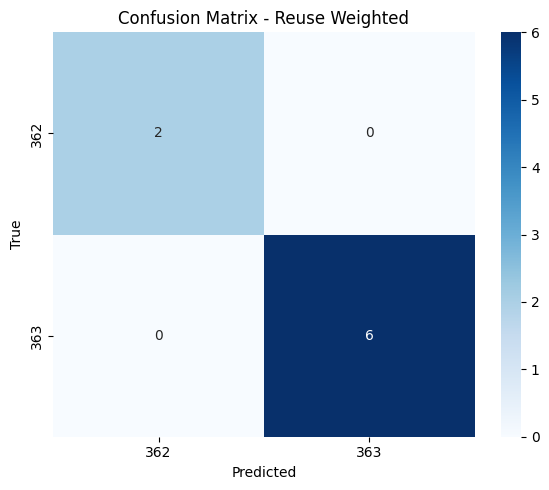

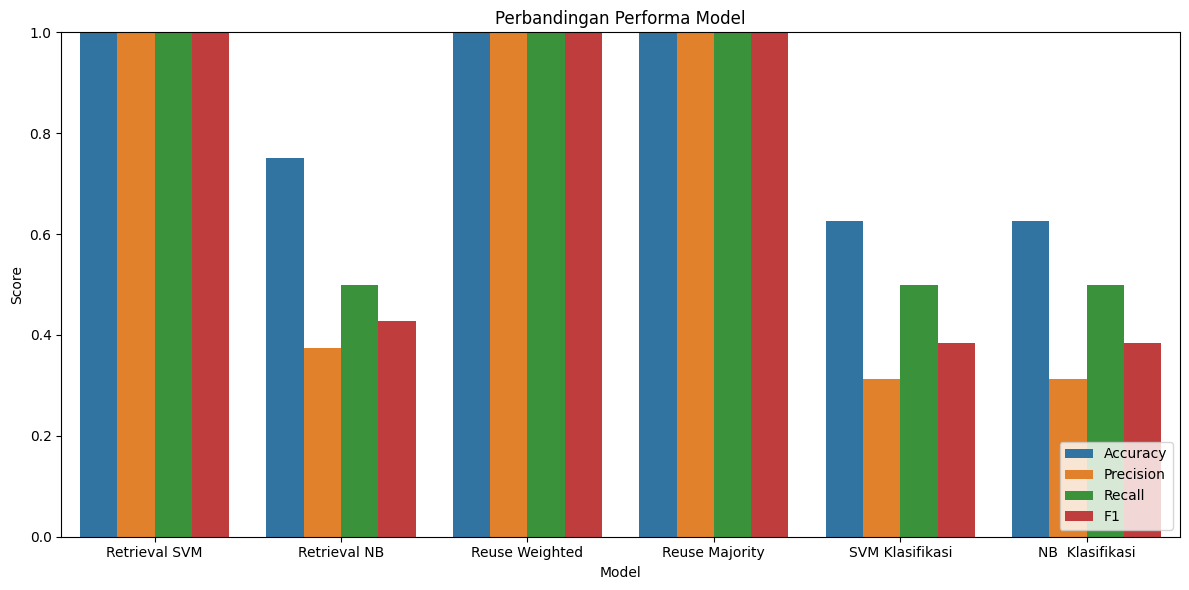

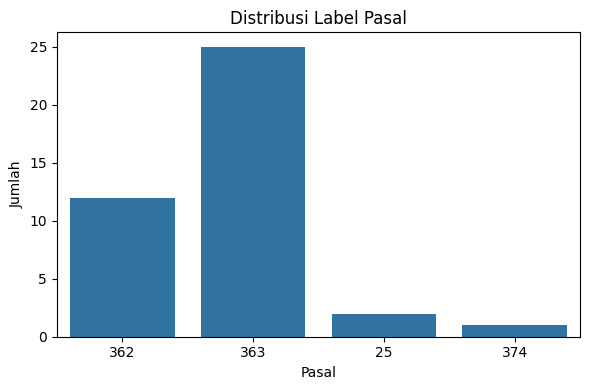


--- REKOMENDASI PERBAIKAN ---
1. Gunakan embedding semantik (IndoBERT/Sentence-BERT) untuk representasi dokumen yang lebih kaya.
2. Lakukan augmentasi data atau SMOTE untuk kelas minoritas (25 dan 374).
3. Tambahkan fitur khusus untuk membedakan Pasal 362 vs 363 (misal ada/tidak unsur pemberatan).
4. Terapkan confidence threshold: jika similarity max < 0.1, sistem abstain (rejection).
5. Evaluasi dengan MRR dan Precision@k untuk retrieval yang lebih informatif.

Seluruh pipeline CBR selesai.


In [8]:
# 6g. Visualisasi
# Confusion Matrix untuk reuse weighted
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_true, res_df['predicted_pasal_weighted'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(set(y_true)), yticklabels=sorted(set(y_true)))
plt.title('Confusion Matrix - Reuse Weighted')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'confusion_reuse_weighted.png'), dpi=150)
plt.show()

# Bar chart perbandingan metrik (hanya numeric)
metrics_plot = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
metrics_plot = metrics_plot[~metrics_plot['Metric'].isin(['CV_Acc'])]
metrics_plot = metrics_plot[metrics_plot['Score'] != '-']
metrics_plot['Score'] = metrics_plot['Score'].astype(float)

plt.figure(figsize=(12,6))
sns.barplot(data=metrics_plot, x='Model', y='Score', hue='Metric')
plt.title('Perbandingan Performa Model')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'model_performance.png'), dpi=150)
plt.show()

# Distribusi label
plt.figure(figsize=(6,4))
sns.countplot(x='label_pasal', data=df)
plt.title('Distribusi Label Pasal')
plt.xlabel('Pasal')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'label_distribution.png'), dpi=150)
plt.show()

# --- 6h. Rekomendasi ---
print('\n--- REKOMENDASI PERBAIKAN ---')
print('1. Gunakan embedding semantik (IndoBERT/Sentence-BERT) untuk representasi dokumen yang lebih kaya.')
print('2. Lakukan augmentasi data atau SMOTE untuk kelas minoritas (25 dan 374).')
print('3. Tambahkan fitur khusus untuk membedakan Pasal 362 vs 363 (misal ada/tidak unsur pemberatan).')
print('4. Terapkan confidence threshold: jika similarity max < 0.1, sistem abstain (rejection).')
print('5. Evaluasi dengan MRR dan Precision@k untuk retrieval yang lebih informatif.')

print('\nSeluruh pipeline CBR selesai.')